# Module 03 — Sections, orbit diagrams & routes to chaos

A continuous flow in $\mathbb{R}^3$ is hard to reason about directly: the trajectory
never repeats, and a tangle of curves on screen tells you little. The classical move —
going back to Poincaré — is to **reduce the flow to a map**: sample the trajectory only
when it pierces a surface, and study the sequence of piercings. A three-dimensional flow
collapses to a two-dimensional map; a periodic orbit becomes a fixed point; a torus
becomes a closed curve; chaos becomes a fractal cloud. Once you have a map, you can sweep
a control parameter and watch the **bifurcation cascade** that routes a system from order
into chaos.

**You will learn to:**
- Draw 2-D and 3-D phase portraits with `traj.plot`.
- Build **Poincaré maps** of a flow with `ts.PoincareMap` / `ts.poincare_section`.
- Use **stroboscopic maps** (`ts.StroboscopicMap`) to section a periodically forced oscillator.
- Extract **return maps** (`ts.return_map`) — the Lorenz $z$-maxima cusp.
- Read **bifurcation / orbit diagrams** (`ts.bifurcation_diagram`), locate period-doubling
  onsets with `.periods()` / `.bifurcation_points()`, and bifurcate a *flow* through a section.

*Estimated time: 30 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import io
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
from IPython.display import Image
print("tsdynamics", ts.__version__)


def show(fig):
    """Render a Matplotlib Figure inline, reliably, everywhere.

    Some ``tsdynamics`` plot helpers return a *bare* Figure that pyplot does not
    manage, so the notebook's auto-display never flushes it. Rasterising through
    ``savefig`` into an ``IPython.display.Image`` sidesteps that — it renders the
    same in nbconvert, Colab and JupyterLab regardless of the active backend.
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=90, bbox_inches="tight")
    plt.close(fig)
    return Image(data=buf.getvalue())

tsdynamics 5.3.1


## 1. Phase portraits: looking at the flow

Before we reduce anything, let's *see* the object. The Rössler system

$$\dot x = -y - z,\qquad \dot y = x + a\,y,\qquad \dot z = b + z(x - c)$$

spirals outward in the $(x,y)$ plane and folds back through a sharp reinjection in $z$.
Its spiral-and-fold geometry is exactly what a Poincaré section will make legible. Let's
integrate it and look at the 3-D portrait and a 2-D projection side by side.

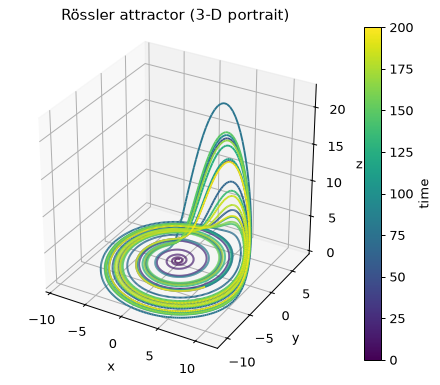

In [2]:
ros = ts.Rossler()                                   # a=0.2, b=0.2, c=5.7 (chaotic)
traj = ros.integrate(final_time=200.0, dt=0.02, backend="jit")

fig3d = traj.plot(kind="phase_portrait_3d", components=["x", "y", "z"], color_by="time")
fig3d.axes[0].set_title("Rössler attractor (3-D portrait)")
show(fig3d)

The `color_by="time"` shading exposes the direction of flow: the trajectory winds
outward in a nearly planar spiral, then the $z$-spike lifts it and folds it back to the
centre. That single fold per loop is the engine of the chaos. Now the flat projection —
the plane the fold will pierce.

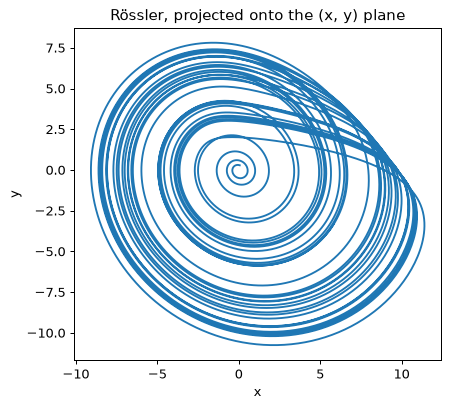

In [3]:
fig2d = traj.plot(kind="phase_portrait_2d", components=["x", "y"])
fig2d.axes[0].set_title("Rössler, projected onto the (x, y) plane")
show(fig2d)

## 2. Poincaré maps: the flow becomes a map

A **Poincaré section** is a codimension-1 surface transverse to the flow. Every time the
trajectory crosses it (in a chosen direction) we record the point. The map
$P:\Sigma\to\Sigma$ that sends one crossing to the next is the **Poincaré (first-return)
map**. It is one dimension lower than the flow and carries all the recurrence structure:
periodic orbits ↔ fixed points of $P$, quasiperiodicity ↔ invariant curves, chaos ↔ a
fractal set.

For Rössler, the natural section is the half-plane $y = 0$ crossed **upward**
($\dot y > 0$). `tsdynamics` refines each crossing with cubic-Hermite interpolation, so
the section is far sharper than the raw integration grid. `ts.PoincareMap` wraps the flow
as a discrete-time object; `.trajectory(n)` marches the whole attractor and collects `n`
crossings in a single engine call.

collected 600 crossings; state cols: 3


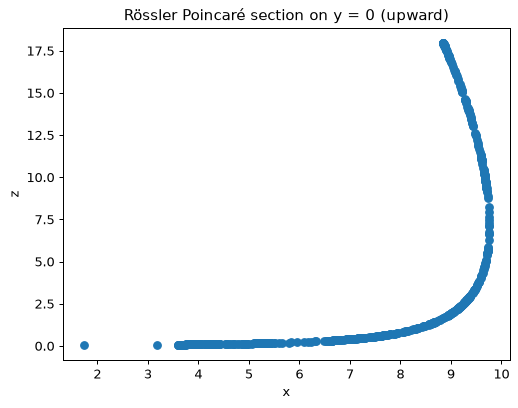

In [4]:
pmap = ts.PoincareMap(ts.Rossler(), plane=("y", 0.0, "up"))   # (axis, offset, direction)
section = pmap.trajectory(600)                                 # -> PoincareSection (a Trajectory)
print("collected", section.y.shape[0], "crossings; state cols:", section.y.shape[1])

fig = section.plot()          # auto-drops the (constant) y-axis, plots the in-plane coords
fig.axes[0].set_title("Rössler Poincaré section on y = 0 (upward)")
fig.axes[0].set_aspect("auto")
show(fig)

The section is a thin, almost one-dimensional arc — visual proof that the Rössler
attractor is *barely more than 2-D* (its correlation dimension is ≈ 2.0, which we
quantify in Module 05). The flow's fold has flattened onto a curve. The equivalent
one-shot helper is `ts.poincare_section`, which returns the same `PoincareSection`
object from a bare system:

In [5]:
sec = ts.poincare_section(ts.Rossler(), plane=("y", 0.0, "up"), n=600, seed=0)
xs, zs = sec.y[:, 0], sec.y[:, 2]    # x and z in the y=0 plane
print(f"section x-range [{xs.min():.2f}, {xs.max():.2f}],  z-range [{zs.min():.3f}, {zs.max():.3f}]")

section x-range [1.29, 9.76],  z-range [0.045, 17.980]


## 3. Stroboscopic maps: sectioning a *forced* oscillator

A periodically **driven** system has a natural clock: the drive period
$T = 2\pi/\Omega$. Sampling the state once per drive cycle is the **stroboscopic map** —
a Poincaré section whose "surface" is a fixed phase of the forcing. It is the standard
way to reveal the strange attractor of a forced oscillator.

The catalogue `Duffing` is the forced double-well oscillator, carrying the drive phase as
a third state variable ($\dot z = \omega$, so $z=\omega t$). With the classic chaotic
parameters $\ddot x + 0.3\,\dot x - x + x^3 = 0.5\cos(1.2\,t)$ the stroboscopic map traces
the celebrated fractal Duffing attractor.

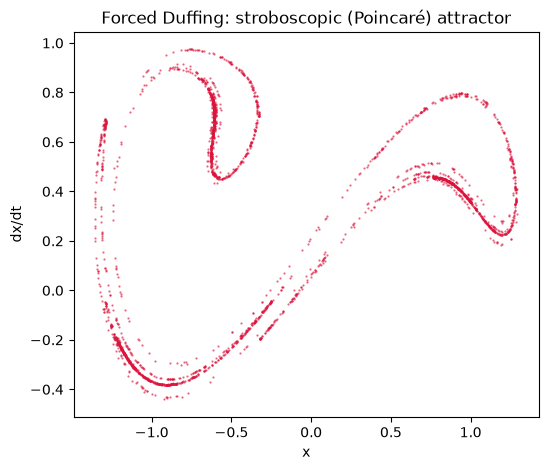

In [6]:
duff = ts.Duffing().with_params(alpha=-1.0, beta=1.0, delta=0.3, gamma=0.5, omega=1.2)
T = 2 * np.pi / duff.params["omega"]                # drive period
strobe = ts.StroboscopicMap(duff, T)
pts = strobe.trajectory(3000, transient=200, ic=[0.5, 0.0, 0.0])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(pts.y[:, 0], pts.y[:, 1], ".", ms=1.2, color="crimson", alpha=0.6)
ax.set(xlabel="x", ylabel="dx/dt", title="Forced Duffing: stroboscopic (Poincaré) attractor")
plt.show()

Each dot is the oscillator's state at the same phase of the drive across thousands of
cycles. The filamentary, self-similar cloud is the signature of a strange attractor — the
same fractal Cantor-set structure Poincaré sections always reveal, here for a system you
could build on a breadboard.

## 4. Return maps: successive extrema

Sometimes the most illuminating "map" isn't a geometric section at all but the sequence of
an **observable's extrema**. Lorenz's own 1963 paper plotted successive *maxima of $z$*:
$z_{n+1}$ against $z_n$. The points fall on a sharp, nearly one-dimensional **cusp** — a
tent-like map — which is why the Lorenz system, for all its 3-D complexity, is chaotic in
essentially the way the tent map is. `ts.return_map(traj, kind="max", component="z")`
builds exactly this.

z-maxima collected: 161


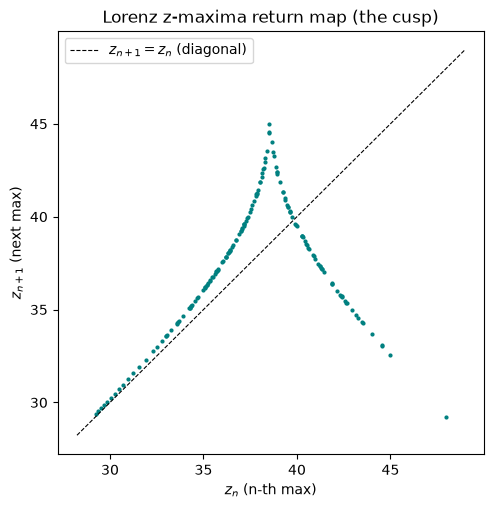

In [7]:
lor_traj = ts.Lorenz().integrate(final_time=120.0, dt=0.005, backend="jit")
rmap = ts.return_map(lor_traj, kind="max", component="z")
zn, znp1 = np.asarray(rmap.current), np.asarray(rmap.successor)   # (z_n, z_{n+1}) pairs
print("z-maxima collected:", zn.size)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(zn, znp1, ".", ms=4, color="teal")
lo, hi = zn.min() - 1, zn.max() + 1
ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="$z_{n+1}=z_n$ (diagonal)")
ax.set(xlabel="$z_n$ (n-th max)", ylabel="$z_{n+1}$ (next max)",
       title="Lorenz z-maxima return map (the cusp)")
ax.legend()
plt.show()

The cusp is single-valued: knowing $z_n$ essentially determines $z_{n+1}$. The map's slope
has magnitude $>1$ everywhere (it stretches), which forces sensitive dependence — a
one-line geometric explanation of Lorenz chaos. The same tool with `kind="poincare"` reads
successive Poincaré crossings; try it on Rössler in the exercises.

## 5. Bifurcation diagrams: the route to chaos

The **orbit (bifurcation) diagram** sweeps a control parameter and, for each value, plots
the asymptotic orbit after discarding a transient. The logistic map
$x_{n+1} = r\,x_n(1-x_n)$ is the canonical example: as $r$ climbs from 2.8 to 4 the single
stable fixed point period-doubles — 1 → 2 → 4 → 8 → … — accumulating at the onset of chaos
near $r_\infty \approx 3.5699$, punctuated by periodic windows (the period-3 window is the
widest).

`ts.bifurcation_diagram` (an alias of `ts.orbit_diagram`) needs a **discrete-time view** —
a map, or a flow wrapped in a section. A bare map is fine here.

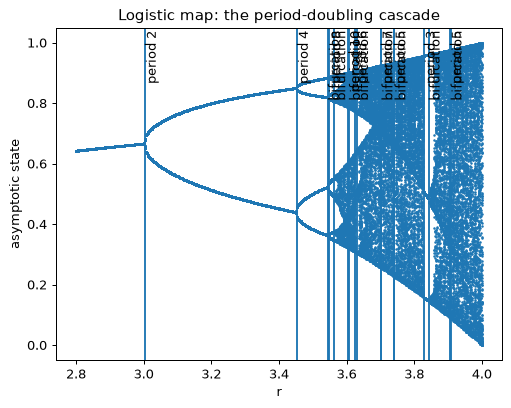

In [8]:
r_vals = np.linspace(2.8, 4.0, 500)
diagram = ts.bifurcation_diagram(ts.Logistic(), "r", r_vals,
                                 n=150, transient=400, component=0)
fig = diagram.plot()
fig.axes[0].set_title("Logistic map: the period-doubling cascade")
show(fig)

The library can *quantify* the cascade. `.periods()` estimates the orbit period at each
swept value, and `.bifurcation_points()` returns the parameter values where the period
changes — the period-doubling onsets. The first two should land near the textbook values
$r_1 = 3$ and $r_2 = 1 + \sqrt{6} \approx 3.449$.

In [9]:
onsets = diagram.bifurcation_points()
print("first detected bifurcation r-values:", np.round(onsets[:4], 4))
print(f"theory:  r1 = 3,   r2 = 1 + sqrt(6) = {1 + np.sqrt(6):.4f}")

periods = diagram.periods()
print("period at r=2.9 :", int(periods[np.argmin(np.abs(r_vals - 2.90))]))  # expect 1
print("period at r=3.2 :", int(periods[np.argmin(np.abs(r_vals - 3.20))]))  # expect 2
print("period at r=3.5 :", int(periods[np.argmin(np.abs(r_vals - 3.50))]))  # expect 4

first detected bifurcation r-values: [3.0032 3.4529 3.5443 3.5491]
theory:  r1 = 3,   r2 = 1 + sqrt(6) = 3.4495
period at r=2.9 : 1
period at r=3.2 : 2
period at r=3.5 : 4


## 6. Bifurcating a *flow* through its section

The section machinery pays off here: because a `PoincareMap` **is** a discrete-time view,
we can feed it straight to `bifurcation_diagram` and get a bifurcation diagram of a
**continuous** system — something you cannot do with the flow directly (a bare flow raises
*"orbit_diagram needs a discrete-time view"*). We sweep Rössler's $c$ parameter and record
the $x$-coordinate of each $y=0$ crossing. Watch the same period-doubling route to chaos
appear, now for an ODE.

*(This is the heaviest cell in the notebook — a few hundred flow integrations behind a
section. We keep the sweep modest so it stays well under the compute budget.)*

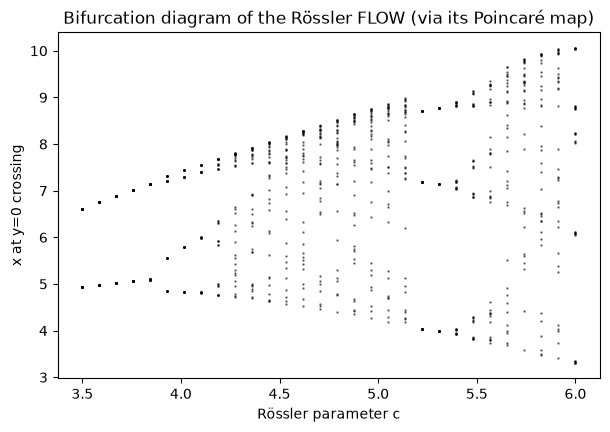

In [10]:
ros_section = ts.PoincareMap(ts.Rossler(), plane=("y", 0.0, "up"))
c_vals = np.linspace(3.5, 6.0, 30)
flow_diagram = ts.orbit_diagram(ros_section, "c", c_vals,
                                n=35, transient=25, component=0)

pts = np.asarray(flow_diagram.points)          # (n_c, n_samples, n_components)
fig, ax = plt.subplots(figsize=(7, 4.5))
for j, c in enumerate(c_vals):
    xs = pts[j, :, 0]
    ax.plot(np.full_like(xs, c), xs, ".", ms=1.5, color="k", alpha=0.5)
ax.set(xlabel="Rössler parameter c", ylabel="x at y=0 crossing",
       title="Bifurcation diagram of the Rössler FLOW (via its Poincaré map)")
plt.show()

At small $c$ the section is a single point — a period-1 limit cycle. As $c$ grows the
points split (period-2, period-4, …) and smear into bands: the flow inherits the logistic
map's period-doubling route to chaos. **Reducing a flow to a map turned an intractable ODE
sweep into a picture you can read at a glance** — the central lesson of this module.

## 🧪 Exercises

**Exercise 1 — Poincaré section of a different flow.**
Build the Poincaré section of the **Lorenz** system on the plane $z = 27$ crossed upward
(this plane passes between Lorenz's two "wings"). Collect ~400 crossings and scatter-plot
the $x$ vs $y$ coordinates of the section. *Hint:* `ts.poincare_section(ts.Lorenz(),
plane=("z", 27.0, "up"), n=...)`; the returned object's `.y` has columns `(x, y, z)`.

In [11]:
# Exercise 1 — your code here
# sec = ts.poincare_section(...)
# ... scatter sec.y[:, 0] vs sec.y[:, 1] ...
# YOUR CODE HERE

**Exercise 2 — the logistic period-doubling onset.**
Zoom the logistic bifurcation diagram into the window $r \in [3.4, 3.6]$ (use `n=200`,
`transient=500`) and confirm from `.bifurcation_points()` that the **second** onset sits
near $r_2 = 1 + \sqrt 6 \approx 3.449$. Print the closest detected value to that theory
number. *Hint:* filter `diagram.bifurcation_points()` to the swept range and find the entry
nearest $1+\sqrt6$.

In [12]:
# Exercise 2 — your code here
# diagram = ts.bifurcation_diagram(ts.Logistic(), "r", np.linspace(3.4, 3.6, ...), ...)
# YOUR CODE HERE

**Exercise 3 — a return map of Rössler.**
Integrate Rössler (`final_time=200, dt=0.02, backend="jit"`) and build the return map of
its **$x$-maxima** with `ts.return_map(traj, kind="max", component="x")`. Plot
$x_{n+1}$ against $x_n$ together with the diagonal. Is the map single-valued (a clean
curve) like the Lorenz cusp? *Hint:* use `rmap.current` and `rmap.successor`.

In [13]:
# Exercise 3 — your code here
# traj = ts.Rossler().integrate(...)
# rmap = ts.return_map(traj, kind="max", component="x")
# YOUR CODE HERE

**Exercise 4 — stroboscopic map at a *periodic* drive amplitude.**
Re-run the forced Duffing stroboscopic map from Section 3 but lower the drive amplitude to
`gamma=0.2` (keep `alpha=-1, beta=1, delta=0.3, omega=1.2`). Plot the section. With weaker
forcing the attractor should collapse from a fractal cloud to a **single point** — the
oscillator locks into a **period-1** response, returning to the same phase-space location
every drive cycle. How many distinct points do you count? *Hint:* copy the Section-3 cell
and change one number.

In [14]:
# Exercise 4 — your code here
# duff = ts.Duffing().with_params(..., gamma=0.2, ...)
# YOUR CODE HERE

## ✅ Solutions

### Solution 1

Lorenz section crossings: 400


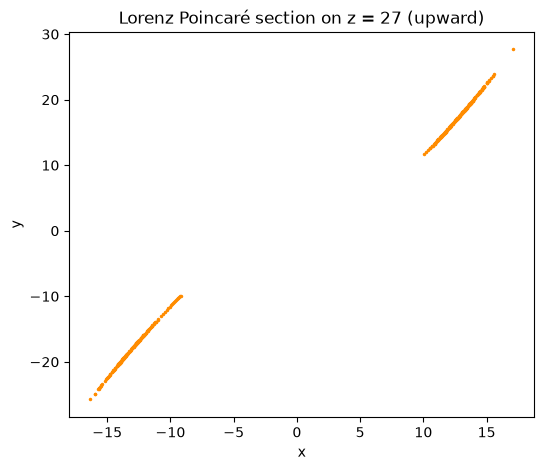

In [15]:
secL = ts.poincare_section(ts.Lorenz(), plane=("z", 27.0, "up"), n=400, seed=0)
print("Lorenz section crossings:", secL.y.shape[0])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(secL.y[:, 0], secL.y[:, 1], ".", ms=3, color="darkorange")
ax.set(xlabel="x", ylabel="y", title="Lorenz Poincaré section on z = 27 (upward)")
plt.show()
# The section splits into two blobs — one per wing of the butterfly — connected by the
# thin bridge the trajectory takes when it switches lobes.

### Solution 2

In [16]:
diagram_zoom = ts.bifurcation_diagram(ts.Logistic(), "r",
                                      np.linspace(3.4, 3.6, 400),
                                      n=200, transient=500, component=0)
onsets_zoom = diagram_zoom.bifurcation_points()
r2_theory = 1 + np.sqrt(6)
# keep only onsets inside the zoom window, pick the one closest to theory
in_window = onsets_zoom[(onsets_zoom >= 3.4) & (onsets_zoom <= 3.6)]
nearest = in_window[np.argmin(np.abs(in_window - r2_theory))]
print(f"detected onsets in [3.4, 3.6]: {np.round(in_window[:5], 4)}")
print(f"nearest to r2 = {r2_theory:.4f}:  r = {nearest:.4f}")

detected onsets in [3.4, 3.6]: [3.4504 3.4509 3.5451 3.5491 3.5647]
nearest to r2 = 3.4495:  r = 3.4504


### Solution 3

x-maxima collected: 33


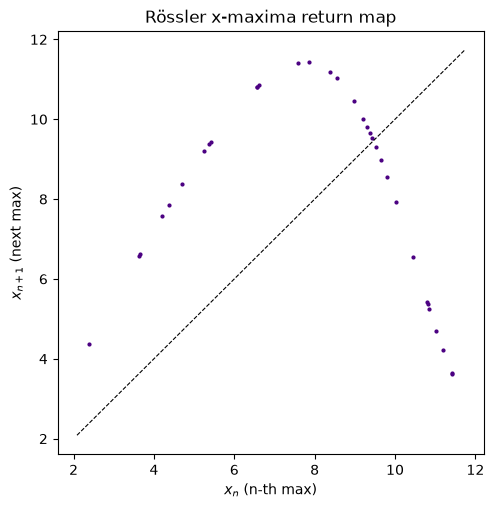

In [17]:
ros_traj = ts.Rossler().integrate(final_time=200.0, dt=0.02, backend="jit")
rmap_x = ts.return_map(ros_traj, kind="max", component="x")
xn, xnp1 = np.asarray(rmap_x.current), np.asarray(rmap_x.successor)
print("x-maxima collected:", xn.size)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(xn, xnp1, ".", ms=4, color="indigo")
lo, hi = xn.min() - 0.3, xn.max() + 0.3
ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
ax.set(xlabel="$x_n$ (n-th max)", ylabel="$x_{n+1}$ (next max)",
       title="Rössler x-maxima return map")
plt.show()
# Like Lorenz, the return map is essentially a single-valued 1-D curve (a smooth
# unimodal hump): the chaotic Rössler flow is well approximated by a 1-D map.

### Solution 4

distinct strobe points (rounded): 1


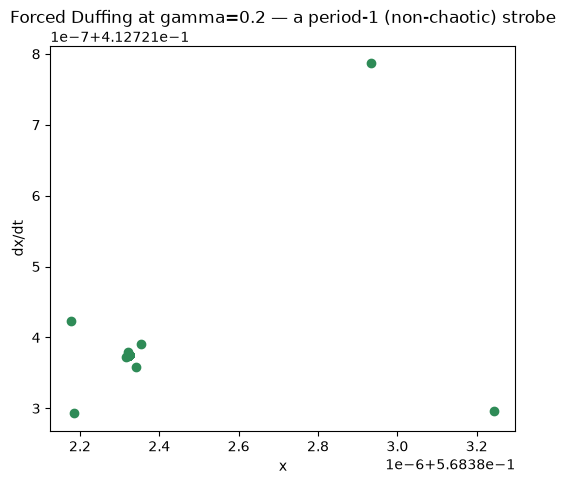

In [18]:
duff_weak = ts.Duffing().with_params(alpha=-1.0, beta=1.0, delta=0.3, gamma=0.2, omega=1.2)
T_weak = 2 * np.pi / duff_weak.params["omega"]
strobe_weak = ts.StroboscopicMap(duff_weak, T_weak)
pts_weak = strobe_weak.trajectory(400, transient=200, ic=[0.5, 0.0, 0.0])

# count distinct points by rounding (a period-p orbit visits p strobe points)
rounded = np.unique(np.round(pts_weak.y[:, :2], 2), axis=0)
print("distinct strobe points (rounded):", rounded.shape[0])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(pts_weak.y[:, 0], pts_weak.y[:, 1], "o", ms=6, color="seagreen")
ax.set(xlabel="x", ylabel="dx/dt",
       title="Forced Duffing at gamma=0.2 — a period-1 (non-chaotic) strobe")
plt.show()
# With weak forcing the strange cloud collapses onto a single point: the oscillator has
# locked into a period-1 response, so it lands at the exact same phase-space location every
# drive cycle. (Every one of the ~400 strobe samples rounds to that one point.)

## Recap / Where next

You reduced flows to maps and read their bifurcation structure:

- **Phase portraits** (`traj.plot`) show the raw geometry; a **Poincaré section**
  (`ts.PoincareMap` / `ts.poincare_section`) collapses a 3-D flow to a 2-D map, exposing
  how nearly-1-D the Rössler attractor is.
- **Stroboscopic maps** (`ts.StroboscopicMap`) section a *forced* oscillator once per drive
  cycle — the standard route to a forced system's strange attractor.
- **Return maps** (`ts.return_map`) turn an observable's extrema into the Lorenz $z$-cusp,
  a 1-D map that *explains* the chaos.
- **Bifurcation diagrams** (`ts.bifurcation_diagram`) chart the period-doubling route to
  chaos, with `.bifurcation_points()` landing on $r_1=3$, $r_2=1+\sqrt6$; wrapping a flow in
  a section lets you bifurcate an **ODE** the same way.

All of these say *"there is chaos here"* geometrically. In **Module 04** we make that
quantitative — Lyapunov exponents, the Kaplan–Yorke dimension, and chaos indicators like
GALI and the 0–1 test put a number on the sensitive dependence you just watched unfold.
The section-and-sweep tools you built here reappear in the capstone, where reducing the
grid model to a map is what makes its stability boundary visible.